#Chat Metrics

##Data Collection

In [3]:
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import seaborn           as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  roc_auc_score,
  classification_report
)
from sklearn.inspection import PartialDependenceDisplay

df = pd.read_parquet('https://huggingface.co/datasets/ddds-Capstone/Datasets/resolve/main/chat_metrics.parquet')

##Processing

In [2]:
features = [
  'month_sin',
  'primary_category_navigation',
  'output_tokens',
  'answer_sentiment',
  'hour_sin',
  'model_calls',
  'primary_category_sunport_amenities',
  'day_sin',
  'question_length',
  'total_tokens'
]

X = df[features]
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.20,
  random_state=42,
  stratify=y
)

#Model
xgb = XGBClassifier(
  n_estimators=300,   #Boosting rounds/trees
  learning_rate=0.20, #Controls how much each new tree contributest to model
  max_depth=1,        #Max deptho or each tree
  random_state=42,
  objective = 'binary:logistic', # Tells XGBoost to do binary classification
  eval_metric='logloss'
)

#Fit
xgb.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb.predict(X_test)

#Probability
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred_xgb))
print('Precision:', precision_score(y_test, y_pred_xgb))
print('Recall:', recall_score(y_test, y_pred_xgb))
print('F1:', f1_score(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7816091954022989
Precision: 0.8
Recall: 0.782608695652174
F1: 0.7912087912087912
ROC-AUC: 0.8563096500530223

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.78      0.77        41
           1       0.80      0.78      0.79        46

    accuracy                           0.78        87
   macro avg       0.78      0.78      0.78        87
weighted avg       0.78      0.78      0.78        87



###Partial Dependence

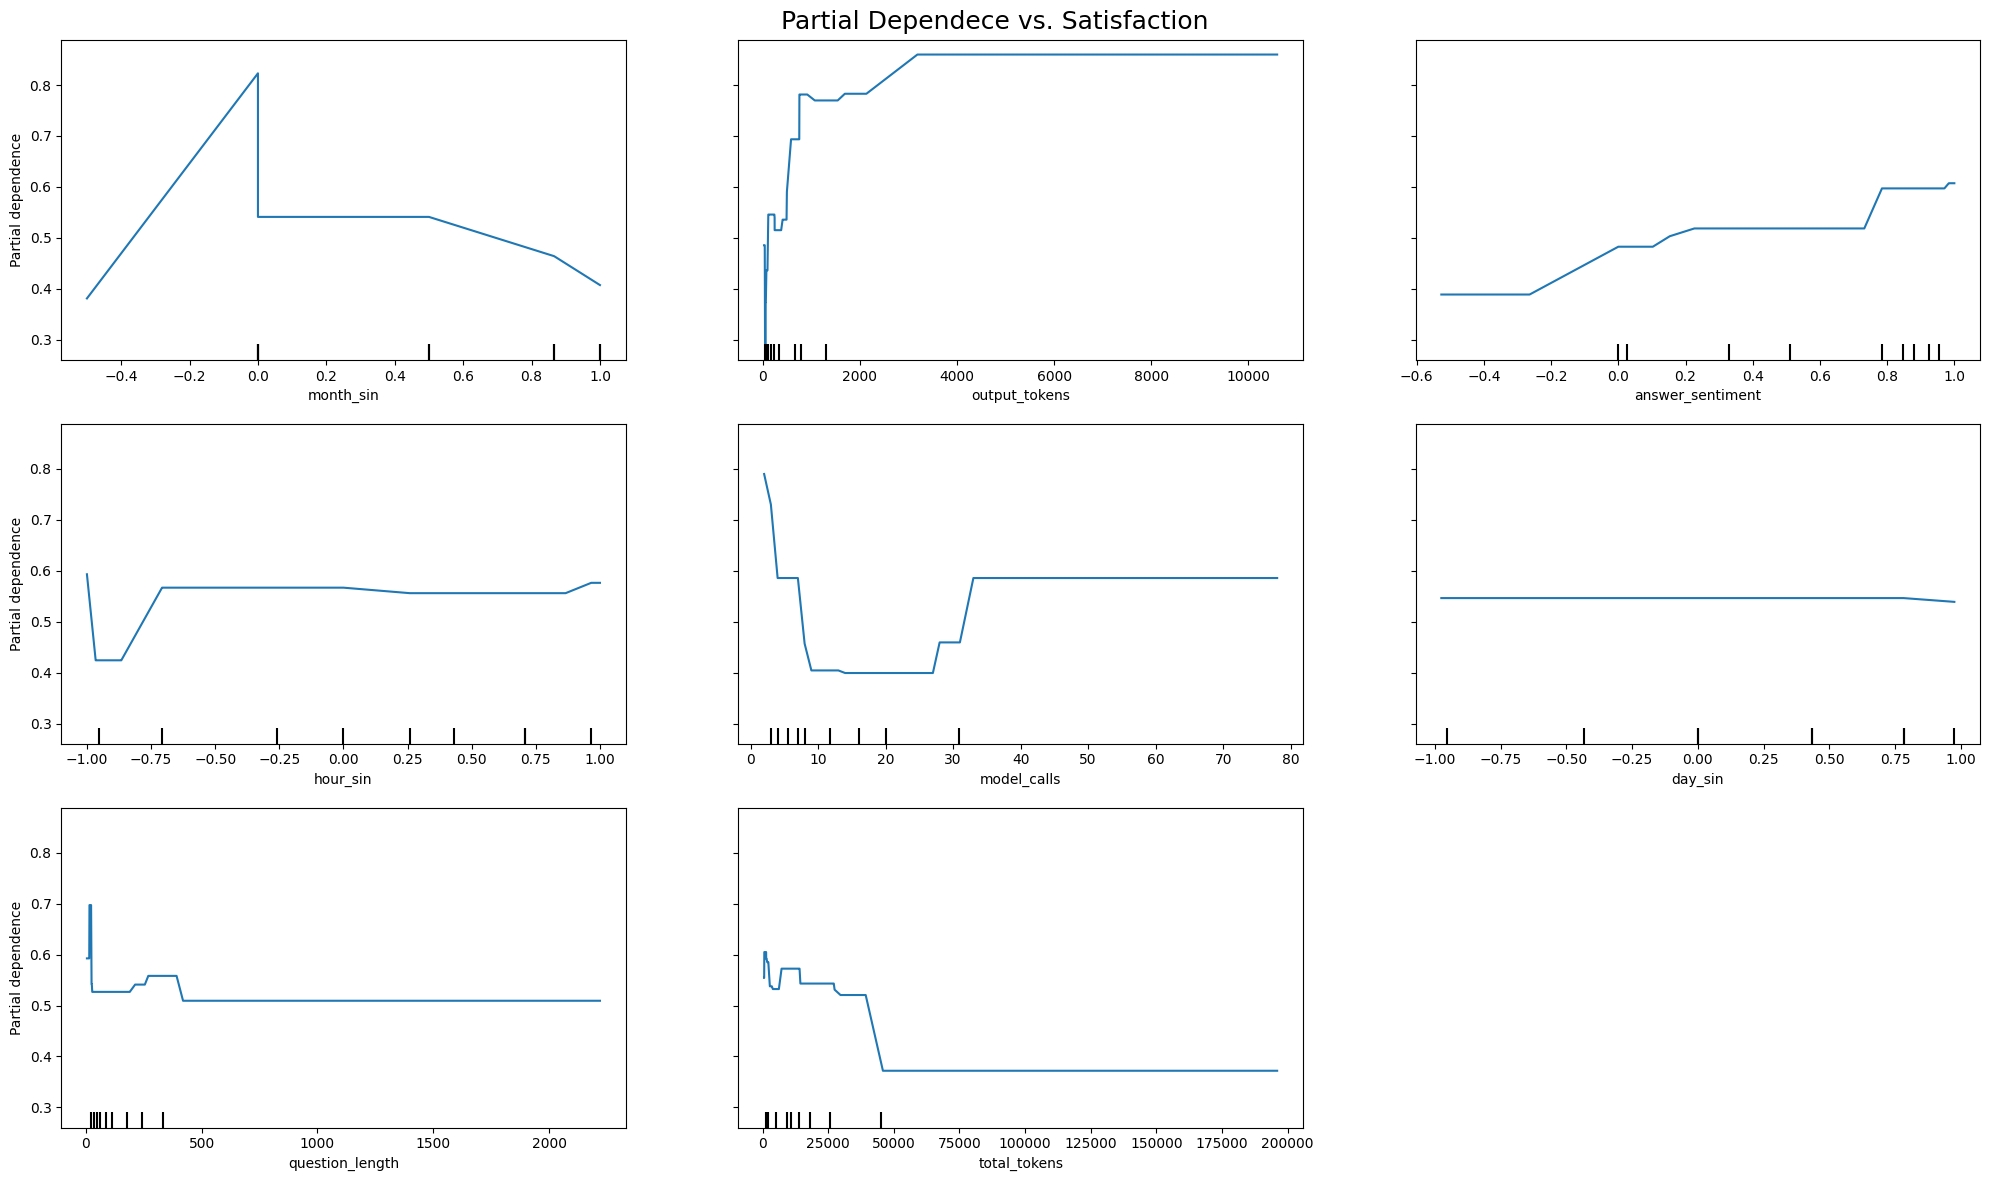

In [6]:
continuous_features = [f for f in features if 'category' not in f]

display = PartialDependenceDisplay.from_estimator(
  xgb,
  X_test,
  features=continuous_features
)

fig = display.figure_
fig.set_size_inches(20,12)
fig.suptitle('Partial Dependece vs. Satisfaction', fontsize=18)

plt.tight_layout()
plt.savefig('partialdependence.png')
plt.show()